# Brain Tumor

|                |   |
:----------------|---|
| **Nombre**     |  Jorge Oviedo Magaña |
| **Fecha**      | 06/04/2026 |
| **Expediente** |  757048 | 

In [17]:
import pandas as pd

df = pd.read_csv("brain_tumor_dataset.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [18]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


In [19]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

#booleanos son aquellos binarios, True or False, 1 o 0, etc.
#Categoricos son listados de nombres
# En la pagina de Kaggle te viene mas información (unidades, etc)


Patient_ID: [    1     2     3 ... 19998 19999 20000]
Age: [73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77]
Gender: ['Male' 'Female']
Tumor_Type: ['Malignant' 'Benign']
Tumor_Size: [5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844]
Location: ['Temporal' 'Parietal' 'Frontal' 'Occipital']
Histology: ['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma']
Stage: ['III' 'II' 'I' 'IV']
Symptom_1: ['Vision Issues' 'Headache' 'Seizures' 'Nausea']
Symptom_2: ['Seizures' 'Headache' 'Vision Issues' 'Nausea']
Symptom_3: ['Seizures' 'Nausea' 'Headache' 'Vision Issues']
Radiation_Treatment: ['No' 'Yes']
Surgery_Performed: ['No' 'Yes']
Chemotherapy: ['No' 'Yes']
Survival_Rate: [51.31257903 46.37327271 47.07222097 ... 89.54380317 83.30678093
 47.43346759]
Tumor_Growth_Rate: [0.11187562 2.16573562 1.88422778 ... 2.33288086 2.38720166 2.464077

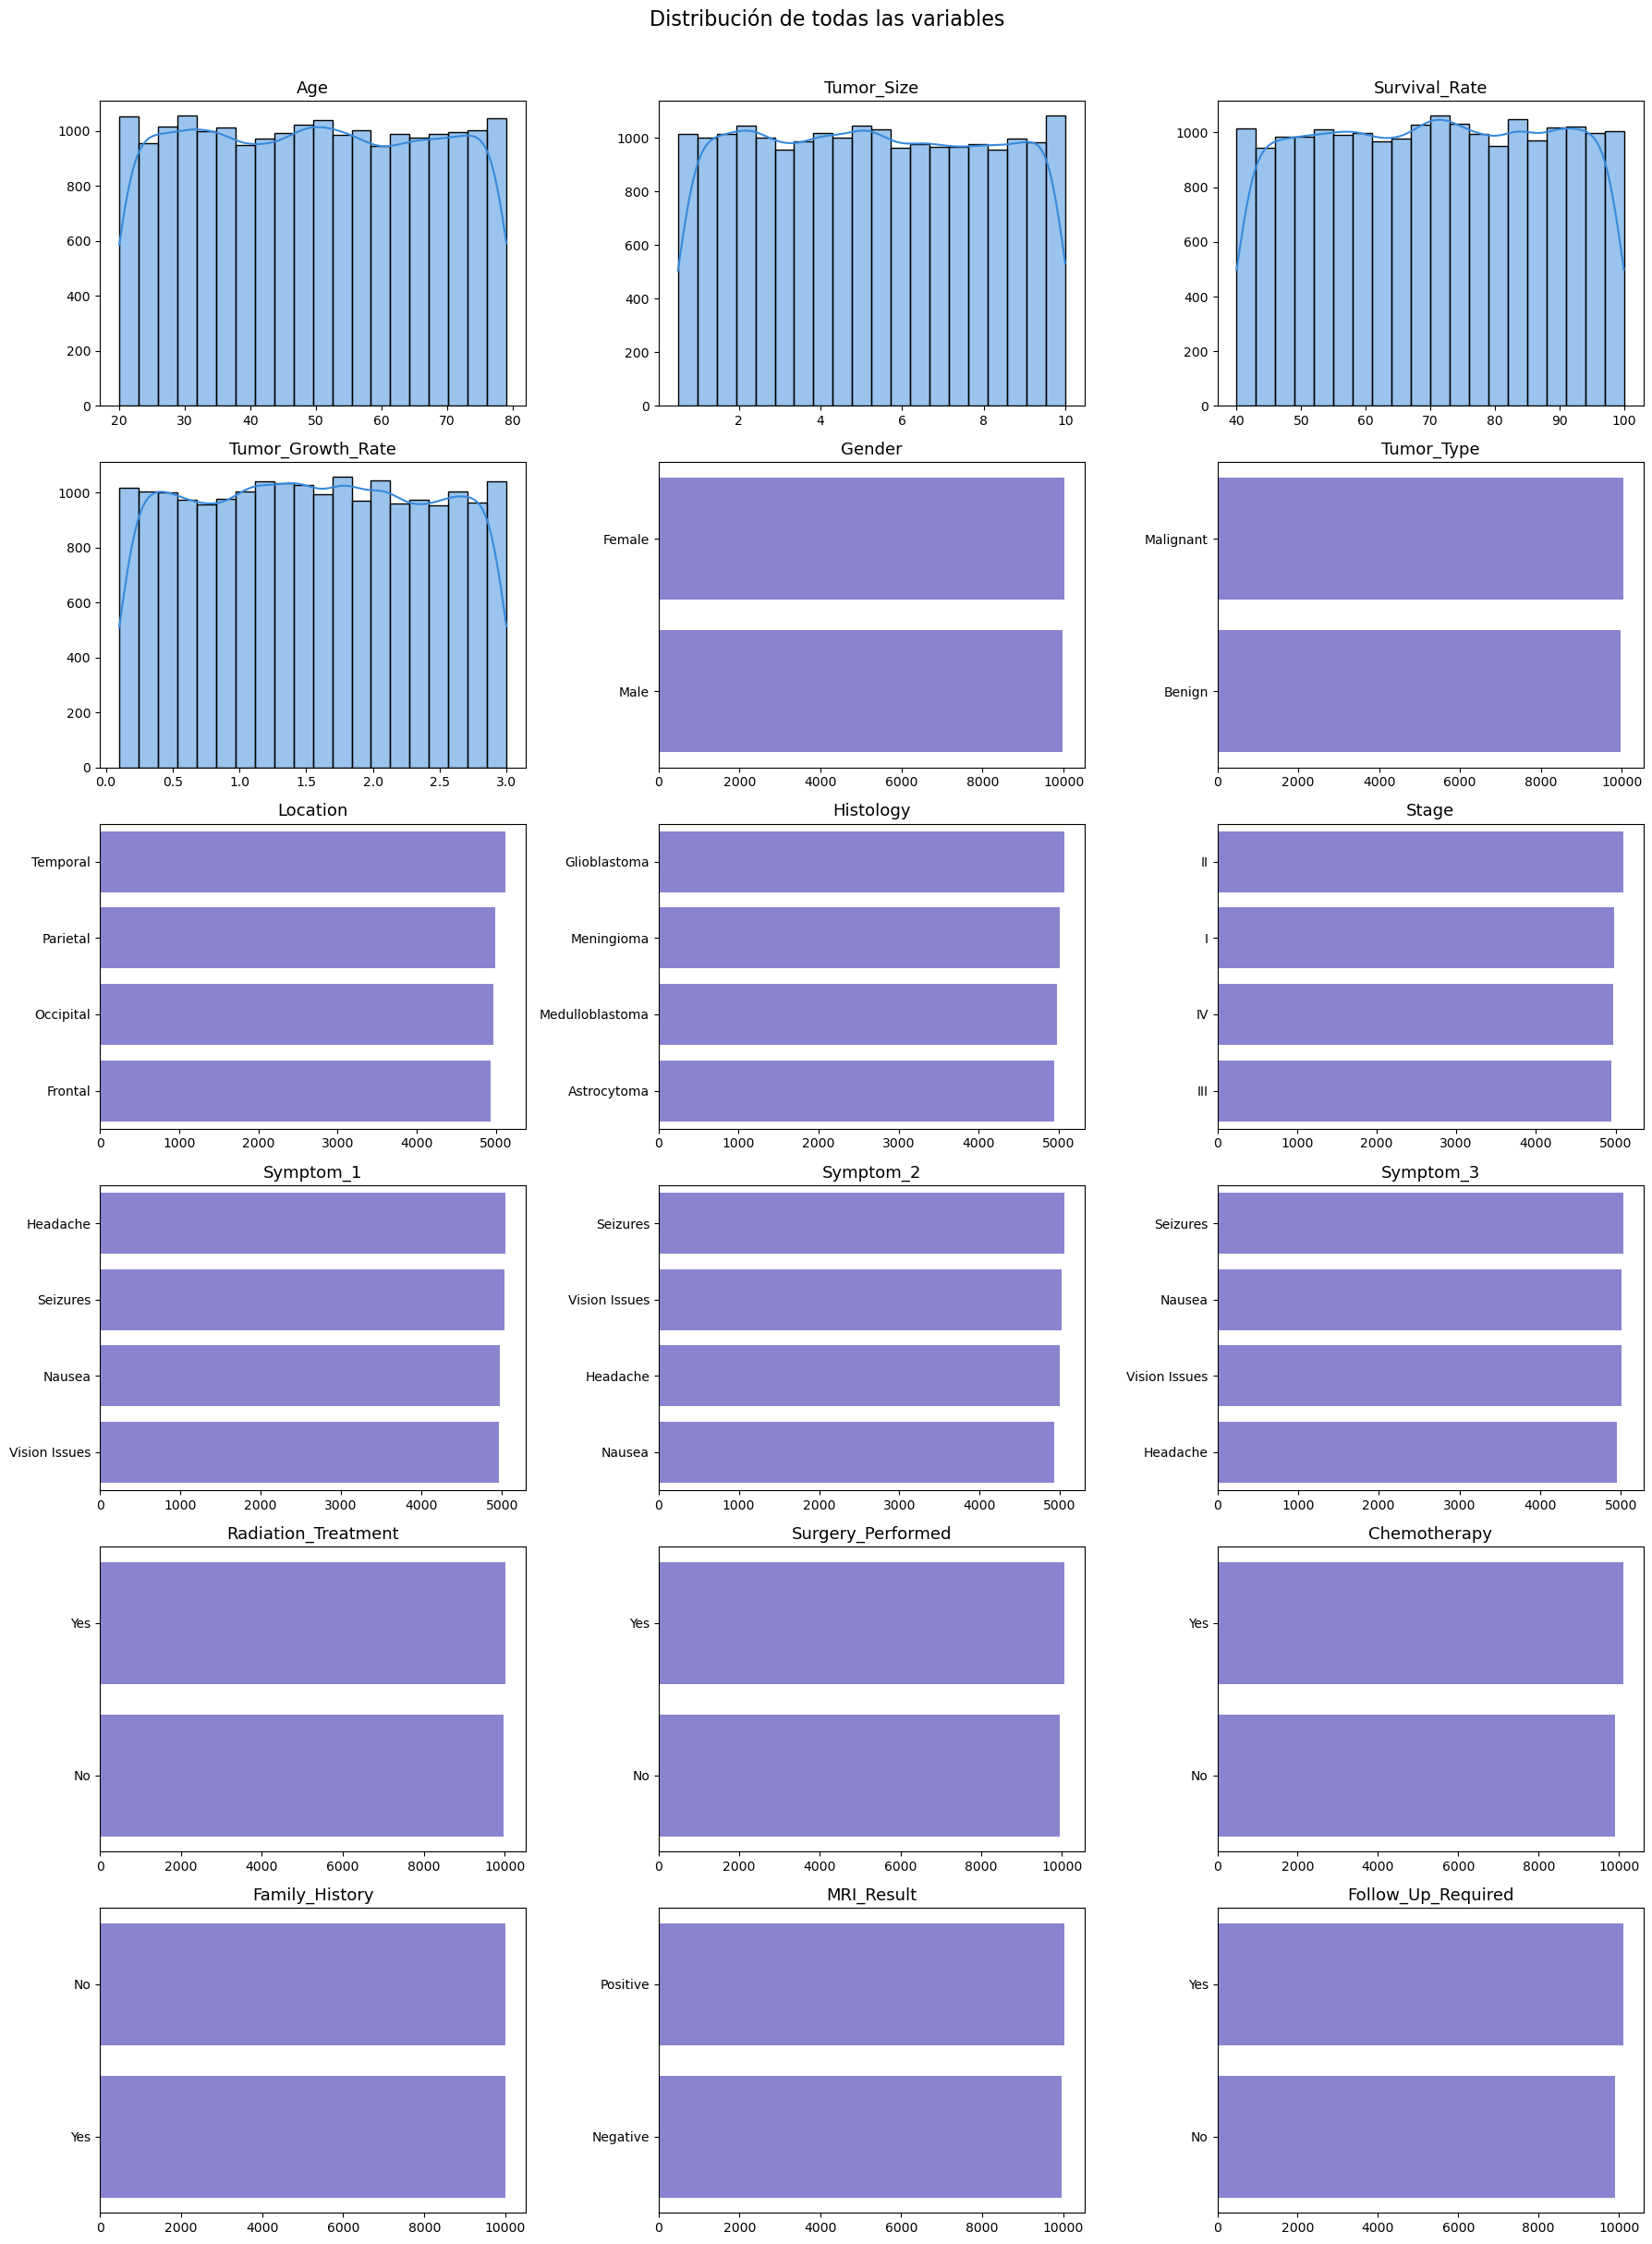

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("brain_tumor_dataset.csv")

num_cols = df.select_dtypes(include="number").drop(columns="Patient_ID").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

all_cols = num_cols + cat_cols
n = len(all_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    if col in num_cols:
        sns.histplot(df[col], bins=20, kde=True, color="#378ADD", ax=ax)
    else:
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, order=order, color="#7F77DD", ax=ax)
    ax.set_title(col, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de todas las variables", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

## Datos
* Tumor_Size (cm)
* Tumor_Growth_Rate (cm/month)
* Survival_Rate (c/c)

## Bools
* Gender
* Tumor_Type (Y)
* Radiation_Treatment
* Surgery_Perfirned
* Family_History
* MRI_Result
* Follow_Up_Required
* Chemotherapy

## Cat
* Location
* Histology
* Symptom_X


# Int
* Age (years)
* Stage (Numeros romanos -> numeros)

In [21]:
y = df["Tumor_Type"]
X = df.drop(columns=["Patient_ID", "Tumor_Type"])

In [22]:
#Transformar categoricos ordinales a numericos
from sklearn.preprocessing import OrdinalEncoder
ordinal_cols = ["Stage"]

X[ordinal_cols] = OrdinalEncoder().fit_transform(X[ordinal_cols])


In [29]:
#transformar booleanos y categoricos a numericos (One-Hot Encoding)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
#---------------------------------------------------------------------------------------------------------------------------------------------------

boolean_cols = ["Gender", "Radiation_Treatment", "Surgery_Performed", "Family_History", "MRI_Result", "Follow_Up_Required", "Chemotherapy"]
cat_cols     = ["Location", "Histology", "Symptom_1", "Symptom_2", "Symptom_3"]
int_cols     = ["Age", "Stage"]
num_cols     = ["Tumor_Size", "Tumor_Growth_Rate", "Survival_Rate"]
#---------------------------------------------------------------------------------------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("bool", OneHotEncoder(drop="first"), boolean_cols),
        ("cat",  OneHotEncoder(drop="first"), cat_cols),
        ("num",  "passthrough",               int_cols),
        ("scaler", StandardScaler(),          num_cols),
    ]
)



In [34]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf"))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

f1_score(y_test, y_pred, pos_label='Malignant')

0.5829037800687286